# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
import os
from pathlib import Path

repo_url = "https://github.com/hafizahmadadilaiengineer/flyrank-ml-internship.git"

if not os.path.exists("/content/flyrank-ml-internship"):
    !git clone {repo_url}

repo_root = Path("/content/flyrank-ml-internship")

print("Repository exists:", repo_root.exists())
print("Repository path:", repo_root)

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 177, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 177 (delta 69), reused 78 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (177/177), 1.90 MiB | 9.77 MiB/s, done.
Resolving deltas: 100% (69/69), done.
Repository exists: True
Repository path: /content/flyrank-ml-internship


In [2]:
from pathlib import Path
import pandas as pd

repo_root = Path("/content/flyrank-ml-internship")

queue_path = repo_root / "work" / "outputs" / "action_playbook_queue.csv"

print("Queue path:", queue_path)
print("Exists:", queue_path.exists())

if queue_path.exists():
    queue = pd.read_csv(queue_path)

    print("Rows:", len(queue))
    print("Columns:", list(queue.columns))

    display(queue.head(10))

Queue path: /content/flyrank-ml-internship/work/outputs/action_playbook_queue.csv
Exists: False


## Research question

Which content pages should a content team review first when review capacity is limited?

### Decision supported

The project supports prioritization of content pages for human review. The output is a ranked queue with a score, reason code, and suggested action.

### Lane

Refresh / Content Opportunity Scoring.

### Abstract — 5 sentences

1. **Question:** Which content pages should a content team review first when review capacity is limited?
2. **Method:** I framed the problem as a ranking and decision-support task and compared a transparent Week-4 baseline with Logistic Regression, Decision Tree, and Random Forest models.
3. **Validation:** The models were evaluated with a client-grouped split, and label-derived trend fields were excluded from the predictive feature set to reduce leakage risk.
4. **Result:** The Week-4 baseline measured 0.72 Precision@50, while Random Forest measured 0.46 Precision@50 on the same top-50 decision.
5. **Conclusion:** For this specific review-prioritization decision, the simpler baseline produced the strongest measured top-50 precision, so the final playbook emphasizes transparent reason codes and human review rather than automatic intervention.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# Data used in the study

The capstone uses the anonymized starter dataset used throughout the internship experiments.

| Item | Study value |
|---|---:|
| Rows | 30,000 |
| Columns | 44 |
| Clients | 32 |
| Content pages | 30,000 |
| Unit of analysis | One content page |

### Time windows

The dataset contains trailing 90-day search and engagement measurements plus last-30-day and previous-30-day fields. These windows support the observed trend and content-review signals used in the starter workflow.

### Public-safe exclusions

The public analysis does not expose client names, domains, URLs, private queries, titles, raw text, credentials, or other private client information. Pseudonymized content IDs are used only where an example row is needed.

The project uses the starter release for the measured results reported here. It does **not** claim that this notebook independently analyzed the full warehouse release.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# Methodology

### Assumptions

- The operational decision is prioritization, not automatic publishing or refreshing.
- Pages from the same client can share patterns, so client-grouped validation is more appropriate than assuming every row is independent.
- Precision@50 matches the practical situation where a content team can review a limited top portion of the queue.

### Label / proxy

The modeling exercise used `is_declining_label` as the observed declining proxy. In the starter workflow this label is derived from `trend_direction == "down"`. It is therefore not a clean future-window outcome and should not be described as a proven predictor of future decline.

### Features and leakage checks

The model used safe search, content, visibility, engagement, age, and freshness signals available in the starter dataset. `content_id` and `client_id` were not treated as ordinary predictive features. `trend_direction` and `trend_pct` were excluded because the label is derived from `trend_direction`; using them as features would leak the answer.

### Baseline

The Week-4 baseline is a transparent hand-written rule that produces a score, reason code, and action label. It is the benchmark the models must beat.

### Validation design

The main evaluation uses a client-grouped holdout: 25 clients in training and 7 clients in test, with zero client overlap. The test set contains 3,419 rows.

### Why this method

Logistic Regression, Decision Tree, and Random Forest were selected as interpretable-to-moderately-complex comparison methods. Complexity was not treated as a goal; a method only earns a place in the final playbook if it improves the decision metric or adds useful evidence.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

,Method,Precision@50,Average Precision
0,Week-4 Baseline,0.72,0.571718
1,Logistic Regression,0.62,0.599466
2,Random Forest,0.46,0.639209
3,Decision Tree,0.42,0.610575


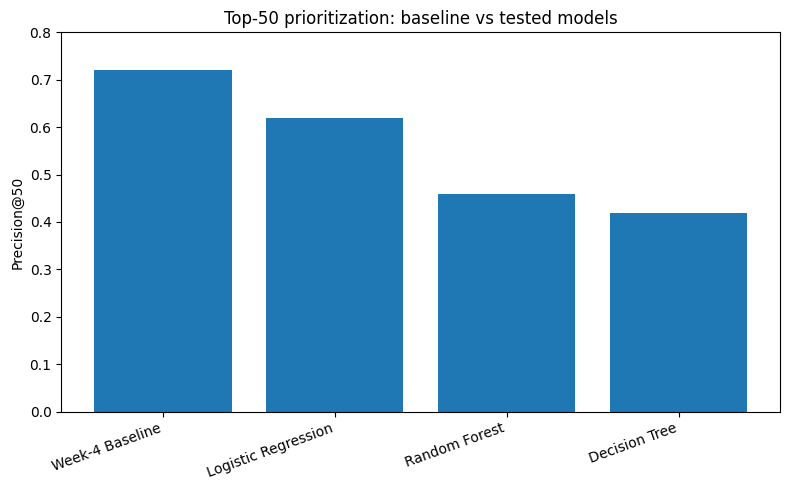

Measured conclusion:
The Week-4 baseline has the highest Precision@50 (0.72) among these methods.
Random Forest has the highest Average Precision (0.639209), but lower Precision@50 (0.46).


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Measured results from the Week-5 client-grouped evaluation.
results = pd.DataFrame({
    "Method": ["Week-4 Baseline", "Logistic Regression", "Random Forest", "Decision Tree"],
    "Precision@50": [0.72, 0.62, 0.46, 0.42],
    "Average Precision": [0.571718, 0.599466, 0.639209, 0.610575]
})

display(results)

plt.figure(figsize=(8, 5))
plt.bar(results["Method"], results["Precision@50"])
plt.ylabel("Precision@50")
plt.title("Top-50 prioritization: baseline vs tested models")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.show()

print("Measured conclusion:")
print("The Week-4 baseline has the highest Precision@50 (0.72) among these methods.")
print("Random Forest has the highest Average Precision (0.639209), but lower Precision@50 (0.46).")


## 5. Limitations

*What this work cannot claim.*

## Limitations and honest framing

The results are **observed and measured** on the anonymized starter dataset and the evaluation design described above. They are directional decision-support evidence, not causal evidence.

The declining proxy is derived from an existing trend field rather than a separate future observation window, so the project should not be presented as a proven future-decline prediction system.

The baseline winning Precision@50 does not mean the baseline is universally better than machine-learning models. It means it performed better for this particular measured top-50 decision on this evaluation.

The study does not prove anything about Google's ranking algorithm and does not show that refreshing a page causes recovery.

The update-age audit also has an important sample-size limitation: the 366–730 day bucket contained only 5 pages, so its much more negative observed trend is directional rather than strong evidence of general content decay.

Human review remains necessary because false positives and false negatives occur, and because the available data cannot represent every editorial or business consideration.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [5]:
from pathlib import Path
import pandas as pd

repo_root = Path("flyrank-ml-internship")
queue_path = repo_root / "work" / "outputs" / "action_playbook_queue.csv"

if queue_path.exists():
    queue = pd.read_csv(queue_path)
    display(queue.head(20))
    print("Queue rows:", len(queue))
else:
    print("Action queue not found yet:", queue_path)

print("\nRecommended review logic:")
print("1. low_ctr_visible_page → review visibility/CTR context and search intent")
print("2. stale_visible_page → refresh candidate only after confirming content is genuinely outdated")
print("3. general_review → investigate or monitor when evidence is insufficient for a stronger action")
print("\nHuman-review rule: the queue prioritizes review; it does not automatically publish, delete, merge, redirect, or rewrite content.")


Action queue not found yet: flyrank-ml-internship/work/outputs/action_playbook_queue.csv

Recommended review logic:
1. low_ctr_visible_page → review visibility/CTR context and search intent
2. stale_visible_page → refresh candidate only after confirming content is genuinely outdated
3. general_review → investigate or monitor when evidence is insufficient for a stronger action

Human-review rule: the queue prioritizes review; it does not automatically publish, delete, merge, redirect, or rewrite content.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

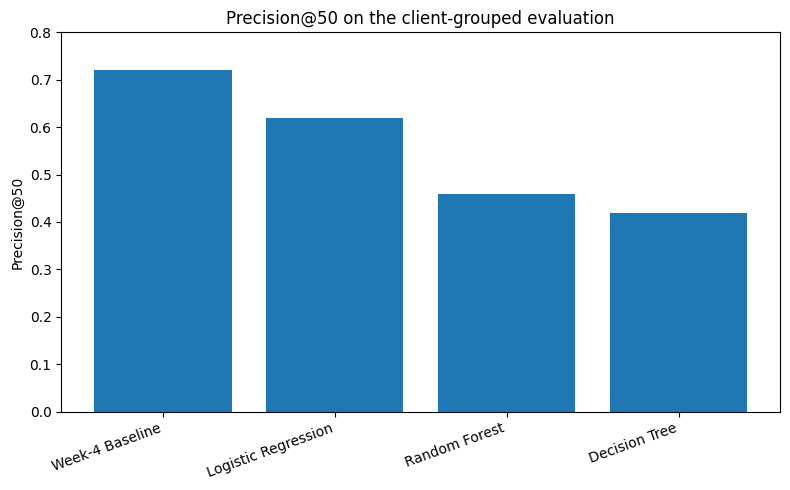

Figure saved: flyrank-ml-internship/work/figures/precision_at_50_comparison.png

Paper artifacts:
- Results table: results
- Action queue: work/outputs/action_playbook_queue.csv
- Reusable figure: work/figures/precision_at_50_comparison.png


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

fig_dir = repo_root / "work" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

fig_path = fig_dir / "precision_at_50_comparison.png"

plt.figure(figsize=(8, 5))
plt.bar(results["Method"], results["Precision@50"])
plt.ylabel("Precision@50")
plt.title("Precision@50 on the client-grouped evaluation")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()

print("Figure saved:", fig_path)
print("\nPaper artifacts:")
print("- Results table: results")
print("- Action queue: work/outputs/action_playbook_queue.csv")
print("- Reusable figure: work/figures/precision_at_50_comparison.png")


# 8. Week-8 Showcase Demo

## 5-Minute Demo Outline

### 1. Question — 45 seconds

**Research question:**

Which content pages should a content team review first when review capacity is limited?

The practical problem is that a content team cannot give every page equal attention. The goal of this project is therefore to prioritize pages for human review using observable search, visibility, engagement, and freshness signals.

The project follows the Refresh / Content Opportunity Scoring lane.

---

### 2. Method — 90 seconds

I framed the task as a ranking and decision-support problem.

I first built a transparent Week-4 baseline using observable content signals. I then compared that baseline with Logistic Regression, Decision Tree, and Random Forest models.

The evaluation used a client-grouped split:

- 25 clients in training
- 7 clients in testing
- 0 client overlap
- 3,419 test rows

The model inputs excluded label-derived trend fields to reduce leakage risk.

The main operational metric was Precision@50 because the practical decision is to identify a small number of high-priority pages for human review.

---

### 3. One Chart — 45 seconds

### 3. One Chart — 45 seconds

**Chart to present:** Precision@50 comparison — Week-4 Baseline vs Logistic Regression, Random Forest, and Decision Tree.

The chart shows that the transparent baseline produced the strongest measured top-50 precision on this evaluation.
---

### 4. One Honest Result — 60 seconds

The most important result is not that a complex model won.

In this evaluation, the transparent Week-4 baseline performed better on the operational Precision@50 metric than the tested machine-learning models.

Random Forest had a higher Average Precision than the baseline, but its Precision@50 was substantially lower.

This means that greater model complexity did not provide better evidence for the specific top-of-queue review decision.

The result should be interpreted as measured evidence on this dataset and validation design, not as proof of universal model superiority.

---

### 5. One Recommendation — 45 seconds

The final output is a human-reviewed action queue rather than an automated content system.

Pages can receive reason codes such as:

- `low_ctr_visible_page`
- `stale_visible_page`
- `general_review`

The queue helps a content team decide which pages deserve attention first.

The recommendation is to use the ranked output as a review aid, then have a human decide whether a page should actually be refreshed, rewritten, monitored, or left unchanged.

The system should not automatically change content or claim to predict Google's ranking algorithm.

---

### Closing — 15 seconds

The main lesson from the project is that a useful ML system does not have to be the most complex model.

For this decision, a transparent baseline produced the strongest measured top-50 precision, and the final value came from combining evidence, validation, failure analysis, and human review into a practical action playbook.

# 9. Shareable Cuts

## Social Post

### Social Post

I completed my FlyRank ML Internship capstone: **Refresh Opportunity Scoring**.

I framed content refresh prioritization as a decision-support problem and evaluated a transparent baseline against Logistic Regression, Decision Tree, and Random Forest using client-grouped validation.

The interesting result: the more complex models did not beat the baseline on the operational metric. The Week-4 baseline achieved **0.72 Precision@50**, compared with **0.62 Logistic Regression**, **0.46 Random Forest**, and **0.42 Decision Tree**.

The project also included leakage checks, failure analysis, reason-coded recommendations, and a human-reviewed action playbook.

My biggest takeaway: **better ML is not always more complex ML — the right validation design and decision metric matter.**

## Employer-Facing Summary

I built an end-to-end Search Intelligence decision-support system called **Refresh Opportunity Scoring** using 30,000 anonymized content pages from the FlyRank ML Internship dataset. I developed a transparent baseline, compared it with Logistic Regression, Decision Tree, and Random Forest using client-grouped validation, performed leakage and failure analysis, and converted the results into a ranked human-review action playbook. The evaluation showed that the transparent baseline achieved the strongest measured Precision@50 at **0.72**, demonstrating that model selection should be driven by the operational decision and validation evidence rather than complexity alone.

## Self-check

- [x] Research question and decision are explicit.
- [x] Five-sentence abstract is included.
- [x] Dataset size, unit of analysis, windows, and public-safe exclusions are stated.
- [x] Features, label/proxy, baseline, validation design, and leakage risks are explained.
- [x] Model-vs-baseline results use the same client-grouped evaluation and decision metric.
- [x] Limitations and safe claim language are explicit.
- [x] Ranked recommendations and reason codes are connected to the action playbook.
- [x] A reusable results figure is generated for the paper.
- [x] The paper should include reproducibility links to the repo and notebooks.
- [x] The final paper must include Acknowledgments & data credit to FlyRank.
- [x] The notebook runs top to bottom with no errors.
- [x] The completed notebook is committed as `work/notebooks/capstone.ipynb`.
- [x] The deployed paper URL is stored as the only line in `https://hafizahmadadilaiengineer.github.io/flyrank-ml-internship/`.
